In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.linear_model import LogisticRegression , LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score , classification_report
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

import warnings
warnings.filterwarnings("ignore")

In [51]:
# loading data

In [52]:
df = pd.read_csv("C:/Users/maan/Desktop/MODULE 5  MINI PROJECT/BAJFINANCE.csv")
df

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,BAJAUTOFIN,EQ,46.95,49.45,50.75,46.50,50.75,50.75,50.05,7600,3.803800e+10,NaN,NaN,NaN
1,2000-01-04,BAJAUTOFIN,EQ,50.75,53.20,53.20,47.90,48.00,48.10,48.56,5000,2.428000e+10,NaN,NaN,NaN
2,2000-01-05,BAJAUTOFIN,EQ,48.10,46.55,47.40,44.60,44.60,44.60,45.47,3500,1.591450e+10,NaN,NaN,NaN
3,2000-01-06,BAJAUTOFIN,EQ,44.60,43.50,46.00,42.10,46.00,45.25,44.43,6200,2.754750e+10,NaN,NaN,NaN
4,2000-01-07,BAJAUTOFIN,EQ,45.25,48.00,48.00,42.00,42.90,42.90,44.44,3500,1.555550e+10,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5230,2021-04-26,BAJFINANCE,EQ,4667.80,4690.00,4829.00,4690.00,4744.00,4736.55,4768.93,2903989,1.384893e+15,175366.0,768523.0,0.2646
5231,2021-04-27,BAJFINANCE,EQ,4736.55,4747.00,4889.85,4746.55,4886.00,4865.05,4818.15,2644997,1.274399e+15,148957.0,777955.0,0.2941
5232,2021-04-28,BAJFINANCE,EQ,4865.05,4915.00,5310.00,4915.00,5255.00,5280.90,5158.33,8576454,4.424018e+15,466644.0,1420176.0,0.1656
5233,2021-04-29,BAJFINANCE,EQ,5280.90,5350.00,5525.00,5330.00,5475.00,5484.85,5440.24,7258486,3.948794e+15,392154.0,1537401.0,0.2118


In [53]:
# EDA (exploratory data analysis)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5235 entries, 0 to 5234
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5235 non-null   object 
 1   Symbol              5235 non-null   object 
 2   Series              5235 non-null   object 
 3   Prev Close          5235 non-null   float64
 4   Open                5235 non-null   float64
 5   High                5235 non-null   float64
 6   Low                 5235 non-null   float64
 7   Last                5235 non-null   float64
 8   Close               5235 non-null   float64
 9   VWAP                5235 non-null   float64
 10  Volume              5235 non-null   int64  
 11  Turnover            5235 non-null   float64
 12  Trades              2456 non-null   float64
 13  Deliverable Volume  4789 non-null   float64
 14  %Deliverble         4789 non-null   float64
dtypes: float64(11), int64(1), object(3)
memory usage: 613.6

In [55]:
df.describe()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5235.000000,5.235000e+03,5.235000e+03,2456.000000,4.789000e+03,4789.000000
mean,1414.245559,1415.326342,1439.089064,1390.673553,1415.299513,1415.278023,1415.529375,6.116085e+05,1.789601e+14,56423.101384,1.611350e+05,0.627860
std,1849.696349,1850.060652,1878.002596,1820.721455,1850.458617,1850.441324,1850.061771,1.897438e+06,5.754942e+14,106039.666275,3.752887e+05,0.244709
min,24.500000,25.200000,25.200000,24.500000,24.500000,24.500000,25.200000,3.000000e+00,1.047000e+07,21.000000,6.000000e+00,0.057500
25%,118.875000,120.000000,123.875000,116.025000,119.000000,119.450000,120.560000,4.899000e+03,7.308218e+10,1682.000000,4.951000e+03,0.450600
50%,610.950000,606.300000,624.000000,598.100000,611.000000,611.000000,611.040000,1.687000e+04,9.145276e+11,13717.500000,1.489000e+04,0.669800
75%,1922.000000,1925.425000,1949.425000,1900.000000,1924.425000,1923.575000,1920.975000,1.191885e+05,3.981237e+13,59527.500000,1.169190e+05,0.828400
max,11393.300000,11300.000000,11770.000000,11294.000000,11386.700000,11393.300000,11490.730000,2.596010e+07,8.787972e+15,979111.000000,6.952047e+06,1.000000


In [56]:
df.isnull().sum()

Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2779
Deliverable Volume     446
%Deliverble            446
dtype: int64

In [57]:
df["Trades"].fillna(df["Trades"].mean(),inplace=True)
df["Deliverable Volume"].fillna(df["Deliverable Volume"].mean(),inplace=True)
df["%Deliverble"].fillna(df["%Deliverble"].mean(),inplace=True)


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5235 entries, 0 to 5234
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                5235 non-null   object 
 1   Symbol              5235 non-null   object 
 2   Series              5235 non-null   object 
 3   Prev Close          5235 non-null   float64
 4   Open                5235 non-null   float64
 5   High                5235 non-null   float64
 6   Low                 5235 non-null   float64
 7   Last                5235 non-null   float64
 8   Close               5235 non-null   float64
 9   VWAP                5235 non-null   float64
 10  Volume              5235 non-null   int64  
 11  Turnover            5235 non-null   float64
 12  Trades              5235 non-null   float64
 13  Deliverable Volume  5235 non-null   float64
 14  %Deliverble         5235 non-null   float64
dtypes: float64(11), int64(1), object(3)
memory usage: 613.6

In [59]:
# Data Visualisation

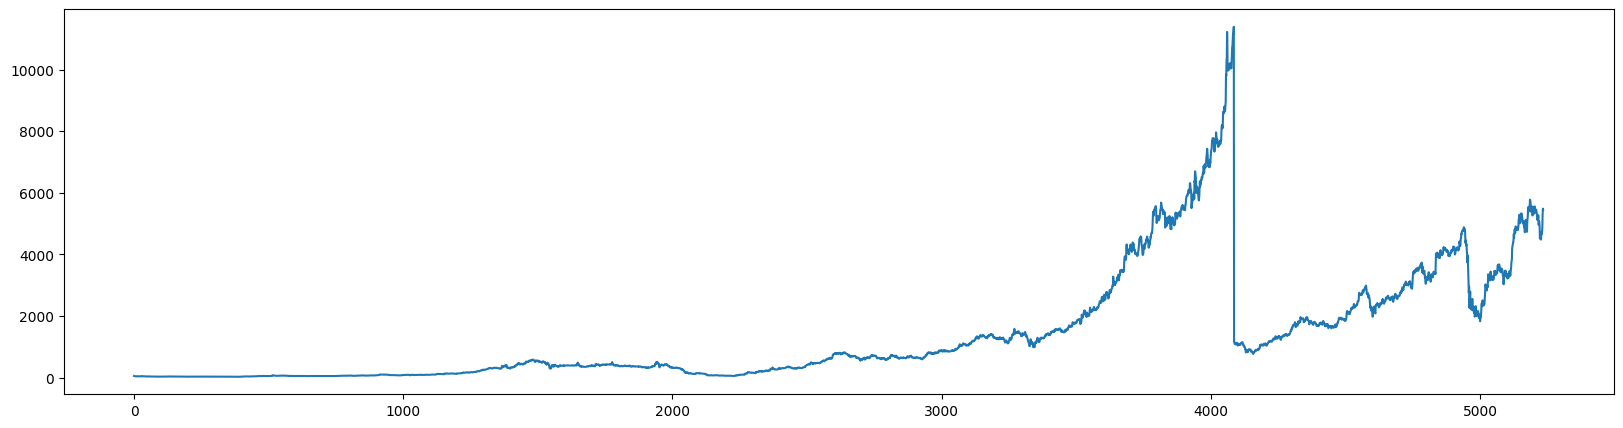

In [60]:
plt.figure(figsize=(20,5))
plt.plot(df["Close"],data=df)
plt.show()

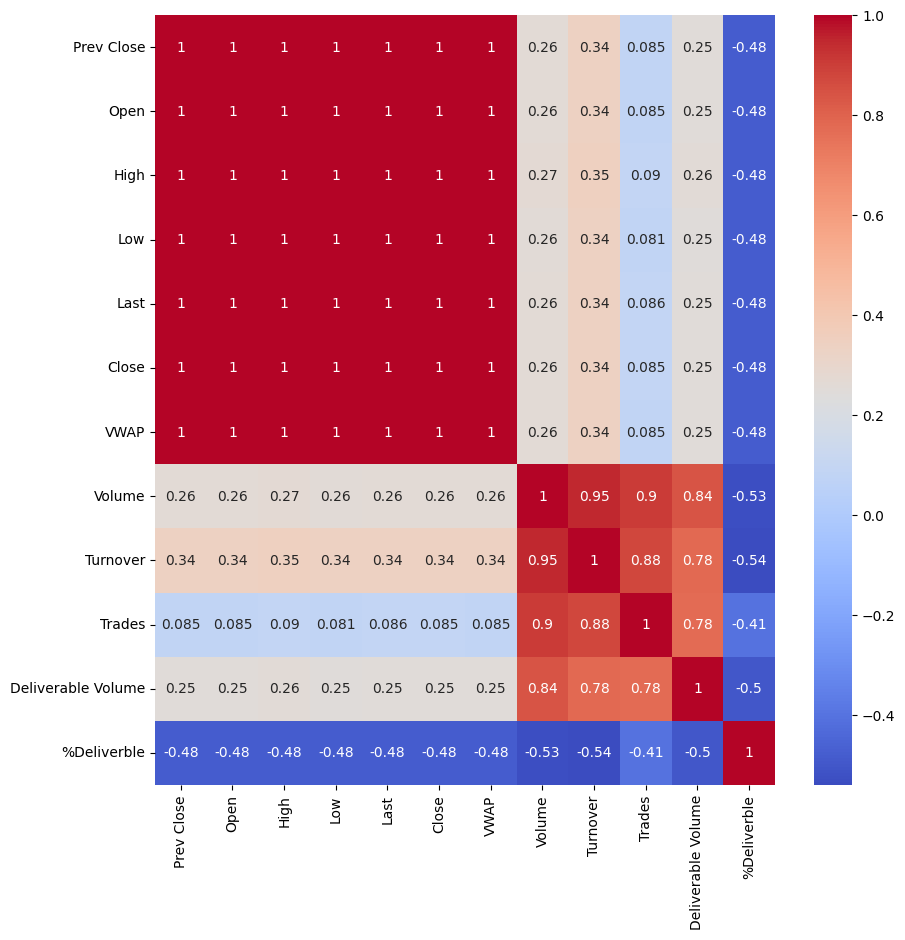

In [61]:
num_col=df.select_dtypes(include=["int","float"]).columns
correlation = df[num_col].corr()

plt.figure(figsize=(10,10))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.show()

In [62]:
category = df.select_dtypes(include=["object"]).columns
category

Index(['Date', 'Symbol', 'Series'], dtype='object')

In [63]:
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoder

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_ca

In [64]:
encoder_array = encoder.fit_transform(df[category])
encoder_array

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 0., 1., 1.]], shape=(5235, 5235))

In [65]:
encoded_columns = encoder.get_feature_names_out(category)

In [66]:
encoderDF= pd.DataFrame(encoder_array,columns=encoded_columns)

In [67]:
df = pd.concat([df.drop(columns=category) , encoderDF],axis=1)
df

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,...,Date_2021-04-19,Date_2021-04-20,Date_2021-04-22,Date_2021-04-23,Date_2021-04-26,Date_2021-04-27,Date_2021-04-28,Date_2021-04-29,Date_2021-04-30,Symbol_BAJFINANCE
0,46.95,49.45,50.75,46.50,50.75,50.75,50.05,7600,3.803800e+10,56423.101384,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,50.75,53.20,53.20,47.90,48.00,48.10,48.56,5000,2.428000e+10,56423.101384,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,48.10,46.55,47.40,44.60,44.60,44.60,45.47,3500,1.591450e+10,56423.101384,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,44.60,43.50,46.00,42.10,46.00,45.25,44.43,6200,2.754750e+10,56423.101384,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,45.25,48.00,48.00,42.00,42.90,42.90,44.44,3500,1.555550e+10,56423.101384,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5230,4667.80,4690.00,4829.00,4690.00,4744.00,4736.55,4768.93,2903989,1.384893e+15,175366.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5231,4736.55,4747.00,4889.85,4746.55,4886.00,4865.05,4818.15,2644997,1.274399e+15,148957.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5232,4865.05,4915.00,5310.00,4915.00,5255.00,5280.90,5158.33,8576454,4.424018e+15,466644.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
5233,5280.90,5350.00,5525.00,5330.00,5475.00,5484.85,5440.24,7258486,3.948794e+15,392154.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [68]:
x= df.drop("Close" , axis=1)
y= df["Close"]

In [69]:
x

,Prev Close,Open,High,Low,Last,VWAP,Volume,Turnover,Trades,Deliverable Volume,...,Date_2021-04-19,Date_2021-04-20,Date_2021-04-22,Date_2021-04-23,Date_2021-04-26,Date_2021-04-27,Date_2021-04-28,Date_2021-04-29,Date_2021-04-30,Symbol_BAJFINANCE
0,46.95,49.45,50.75,46.50,50.75,50.05,7600,3.803800e+10,56423.101384,1.611350e+05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,50.75,53.20,53.20,47.90,48.00,48.56,5000,2.428000e+10,56423.101384,1.611350e+05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,48.10,46.55,47.40,44.60,44.60,45.47,3500,1.591450e+10,56423.101384,1.611350e+05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,44.60,43.50,46.00,42.10,46.00,44.43,6200,2.754750e+10,56423.101384,1.611350e+05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,45.25,48.00,48.00,42.00,42.90,44.44,3500,1.555550e+10,56423.101384,1.611350e+05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5230,4667.80,4690.00,4829.00,4690.00,4744.00,4768.93,2903989,1.384893e+15,175366.000000,7.685230e+05,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5231,4736.55,4747.00,4889.85,4746.55,4886.00,4818.15,2644997,1.274399e+15,148957.000000,7.779550e+05,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5232,4865.05,4915.00,5310.00,4915.00,5255.00,5158.33,8576454,4.424018e+15,466644.000000,1.420176e+06,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
5233,5280.90,5350.00,5525.00,5330.00,5475.00,5440.24,7258486,3.948794e+15,392154.000000,1.537401e+06,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [70]:
y

0         50.75
1         48.10
2         44.60
3         45.25
4         42.90
         ...   
5230    4736.55
5231    4865.05
5232    5280.90
5233    5484.85
5234    5451.90
Name: Close, Length: 5235, dtype: float64

In [71]:
X_train, X_test,Y_train, Y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [72]:
X_train

,Prev Close,Open,High,Low,Last,VWAP,Volume,Turnover,Trades,Deliverable Volume,...,Date_2021-04-19,Date_2021-04-20,Date_2021-04-22,Date_2021-04-23,Date_2021-04-26,Date_2021-04-27,Date_2021-04-28,Date_2021-04-29,Date_2021-04-30,Symbol_BAJFINANCE
378,28.00,27.50,27.50,27.50,27.50,27.50,100,2.750000e+08,56423.101384,1.611350e+05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3414,1481.55,1453.25,1495.80,1453.25,1478.00,1478.59,22562,3.335984e+12,1234.000000,1.833300e+04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1912,332.70,330.00,330.00,320.25,326.00,325.04,797,2.590580e+10,56423.101384,5.800000e+02,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4880,4118.35,4120.00,4139.05,4065.00,4107.00,4100.38,969708,3.976176e+14,81001.000000,2.975280e+05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3235,1174.30,1165.05,1171.85,1105.00,1130.00,1134.25,43957,4.985802e+12,1800.000000,3.601300e+04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3092,1037.60,1031.25,1062.95,1028.00,1062.95,1055.40,20430,2.156191e+12,290.000000,1.938400e+04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3772,4284.70,4220.00,4365.70,4170.00,4365.70,4255.13,25933,1.103483e+13,3659.000000,1.100500e+04,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5191,5376.85,5420.00,5504.65,5350.00,5360.00,5423.47,2190245,1.187874e+15,113673.000000,3.374490e+05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5226,4616.60,4450.00,4504.00,4362.00,4478.80,4435.76,3426507,1.519916e+15,251715.000000,1.107890e+06,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [73]:
Y_train

378       27.50
3414    1483.30
1912     324.55
4880    4102.05
3235    1136.50
         ...   
3092    1058.20
3772    4324.85
5191    5383.70
5226    4479.60
860       62.15
Name: Close, Length: 4188, dtype: float64

In [74]:
print(f"\nTraining set class distribution:")
Y_train.value_counts(normalize=True)

print(f"\nTesting set class distribution:")
Y_test.value_counts(normalize=True)





Training set class distribution:

Testing set class distribution:


Close
30.00      0.003820
34.00      0.003820
48.00      0.003820
29.40      0.002865
29.00      0.002865
             ...   
26.75      0.000955
1371.15    0.000955
62.80      0.000955
1182.15    0.000955
181.65     0.000955
Name: proportion, Length: 990, dtype: float64

In [75]:
# feature scaling

In [76]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [77]:
X_train = pd.DataFrame(X_train)
X_train

,0,1,2,3,4,5,6,7,8,9,...,5236,5237,5238,5239,5240,5241,5242,5243,5244,5245
0,-0.761057,-0.760939,-0.761991,-0.759707,-0.760638,-0.760868,-0.321577,-0.312165,-0.005684,-0.005254,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-1.007670
1,0.045254,0.027932,0.037531,0.042433,0.041572,0.041710,-0.310058,-0.306447,-0.745705,-0.392667,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,0.992388
2,-0.592034,-0.593565,-0.597273,-0.595003,-0.595550,-0.596303,-0.321219,-0.312121,-0.005684,-0.440830,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-1.007670
3,1.507936,1.503452,1.476838,1.511826,1.495561,1.491785,0.175649,0.369404,0.323878,0.364771,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,0.992388
4,-0.125183,-0.131530,-0.138867,-0.153496,-0.150892,-0.148740,-0.299086,-0.303619,-0.738116,-0.344702,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,0.992388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4183,-0.201013,-0.205562,-0.198166,-0.196817,-0.187974,-0.192351,-0.311151,-0.308469,-0.758363,-0.389816,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,0.992388
4184,1.600213,1.558783,1.600253,1.570900,1.638637,1.577375,-0.308329,-0.293250,-0.713189,-0.412547,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,0.992388
4185,2.206049,2.222746,2.220436,2.234778,2.188542,2.223567,0.801554,1.724008,0.761971,0.473074,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,0.992388
4186,1.784324,1.686042,1.675561,1.678920,1.701188,1.677279,1.435523,2.293173,2.612954,2.563230,...,64.707032,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,0.992388


In [78]:
X_test = pd.DataFrame(X_test)
X_test

,0,1,2,3,4,5,6,7,8,9,...,5236,5237,5238,5239,5240,5241,5242,5243,5244,5245
0,-0.197962,-0.205174,-0.199772,-0.194623,-0.189606,-0.198678,-0.319583,-0.311452,-0.758082,-0.434405,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,0.992388
1,-0.674022,-0.671581,-0.674050,-0.673824,-0.675356,-0.674221,-0.320032,-0.312067,-0.005684,-0.435648,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-1.007670
2,-0.757396,-0.756513,-0.757635,-0.755206,-0.756213,-0.756443,-0.321602,-0.312165,-0.005684,-0.005254,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-1.007670
3,-0.513209,-0.513336,-0.518317,-0.508418,-0.513144,-0.513384,-0.296523,-0.308180,-0.005684,-0.326148,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-1.007670
4,-0.437185,-0.435320,-0.433916,-0.440989,-0.436297,-0.433430,-0.297290,-0.307125,-0.739618,-0.381598,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,0.992388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1042,-0.760502,-0.762046,-0.762399,-0.760832,-0.761053,-0.761609,-0.321531,-0.312164,-0.005684,-0.005254,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-1.007670
1043,-0.049991,-0.055976,-0.020624,-0.042887,-0.022029,-0.029041,-0.309152,-0.306533,-0.737834,-0.394729,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,0.992388
1044,-0.740782,-0.741850,-0.741843,-0.740297,-0.741170,-0.741399,-0.320767,-0.312147,-0.005684,-0.438117,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-1.007670
1045,-0.122576,-0.112219,-0.116270,-0.116926,-0.125119,-0.120516,-0.315458,-0.309721,-0.755869,-0.418076,...,-0.015454,-0.015454,-0.015454,0.0,-0.015454,-0.015454,-0.015454,0.0,-0.015454,0.992388


In [79]:
# model building

In [80]:
linear = LinearRegression()
linear.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [81]:
y_pred_linear_train = linear.predict(X_train)
y_pred_linear_test = linear.predict(X_test)
print("linear model prediction completed")

linear model prediction completed


In [82]:
decision = DecisionTreeRegressor()
decision.fit(X_train,Y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [83]:
y_pred_decision_train = decision.predict(X_train)
y_pred_decision_test = decision.predict(X_test)
print("decision model prediction completed")

decision model prediction completed


In [84]:
random = RandomForestRegressor()
random.fit(X_train,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [85]:
y_pred_random_train = random.predict(X_train)
y_pred_random_test = random.predict(X_test)
print("random model prediction completed")

random model prediction completed


In [86]:
#  model evaluaton

In [87]:
def evaluate(y_true_train, y_pred_train,y_true_test,y_pred_test,model_name):
    
    # calculate training set
    mae = mean_absolute_error(y_true_train,y_pred_train)
    mse = mean_squared_error(y_true_train,y_pred_train)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_train,y_pred_train)

    # calculate testing set
    mae_test = mean_absolute_error(y_true_test,y_pred_test)
    mse_test = mean_squared_error(y_true_test,y_pred_test)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_true_test,y_pred_test)



    print(f"\n{'='*40}")
    print(f"📊 {model_name} Performance")
    print(f"{'='*40}")
    print(f"{'Metric':<15} {'Training':<15} {'Test':<15}")
    print(f"{'-'*45}")
    print(f"{'MAE':<15} {mae:<15.2f} {mae_test:<15.2f}")
    print(f"{'MSE':<15} {mse:<15.2f} {mse_test:<15.2f}")
    print(f"{'RMSE':<15} {rmse:<15.2f} {rmse_test:<15.2f}")
    print(f"{'R² Score':<15} {r2:<15.4f} {r2_test:<15.4f}")
    print(f"{'='*40}")


In [88]:
evaluate(Y_train,y_pred_linear_train,Y_test,y_pred_linear_test,"Linear Regression")


evaluate(Y_train,y_pred_decision_train,Y_test,y_pred_decision_test,"Decision Tree")


evaluate(Y_train,y_pred_random_train,Y_test,y_pred_random_test,"Random Forest")



📊 Linear Regression Performance
Metric          Training        Test           
---------------------------------------------
MAE             0.00            142.71         
MSE             0.00            78287.70       
RMSE            0.00            279.80         
R² Score        1.0000          0.9806         

📊 Decision Tree Performance
Metric          Training        Test           
---------------------------------------------
MAE             0.00            7.25           
MSE             0.00            303.17         
RMSE            0.00            17.41          
R² Score        1.0000          0.9999         

📊 Random Forest Performance
Metric          Training        Test           
---------------------------------------------
MAE             2.06            4.99           
MSE             51.29           157.05         
RMSE            7.16            12.53          
R² Score        1.0000          1.0000         


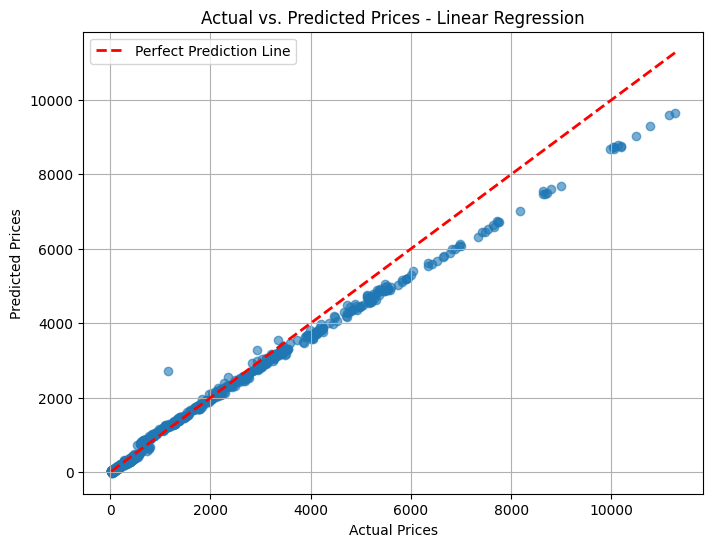

✅ Final Model Selected: Linear Regression


In [89]:
best_model = linear
best_model_name = "Linear Regression"
y_pred_best_test = y_pred_linear_test

plt.figure(figsize=(8, 6))
plt.scatter(Y_test, y_pred_best_test, alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title(f"Actual vs. Predicted Prices - {best_model_name}")
plt.legend()
plt.grid(True)
plt.show()

print(f"✅ Final Model Selected: {best_model_name}")


In [98]:
new_data = {
    "Date"       :      "2021-04-29"	      ,
"Symbol"         :       "BAJAUTOFIN",
"Series"         :       "EQ",
"Prev Close"     :       39.9,
"Open"           :       42.05,
"High"           :       37.75,
"Low"            :       39.5,
"Last"           :       41.3,
"Close"          :       41.3,
"VWAP"           :       39.67,
"Volume"         :       10700,
"Turnover"       :       11307000000,
"Trades"        :        25629,
"Deliverable Volume" :   40491,
"%Deliverble"      :     0.7621,
}

In [101]:
new_data_df = pd.DataFrame([new_data])
new_data_df

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2021-04-29,BAJAUTOFIN,EQ,39.9,42.05,37.75,39.5,41.3,41.3,39.67,10700,11307000000,25629,40491,0.7621


In [100]:
newdata_encoderarray = encoder.transform(new_data_df[category])
newdata_encoded = pd.DataFrame(newdata_encoderarray,columns=encoded_columns)


In [103]:
newdata_process = pd.concat([new_data_df.drop(columns=category),newdata_encoded],axis=1)
newdata_process

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,...,Date_2021-04-19,Date_2021-04-20,Date_2021-04-22,Date_2021-04-23,Date_2021-04-26,Date_2021-04-27,Date_2021-04-28,Date_2021-04-29,Date_2021-04-30,Symbol_BAJFINANCE
0,39.9,42.05,37.75,39.5,41.3,41.3,39.67,10700,11307000000,25629,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [106]:
newdata_process = newdata_process.reindex(columns=X_train.columns,fill_value=0)
newdata_process


,0,1,2,3,4,5,6,7,8,9,...,5236,5237,5238,5239,5240,5241,5242,5243,5244,5245
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [108]:
new_data_scaled = scaler.transform(newdata_process)
new_data_scaled

array([[-0.7765893 , -0.77615497, -0.77696505, ...,  0.        ,
        -0.01545427, -1.00767029]], shape=(1, 5246))

In [109]:
predicted_price = best_model.predict(new_data_scaled)
predicted_price

array([117.11895405])

In [111]:
print(f"\n💰 Predicted price for the new data using {best_model_name}: ${predicted_price[0]:,.2f}")


💰 Predicted price for the new data using Linear Regression: $117.12
